In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report,confusion_matrix,f1_score,precision_score,recall_score,accuracy_score,roc_auc_score,precision_recall_curve,roc_curve ,average_precision_score
from sklearn.model_selection import StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
RANDOM_STATE=42
DATA_PATH='/content/drive/MyDrive/data/'
np.random.seed(RANDOM_STATE)

#Random Forest Binary Classification for CMAPSS Anomaly Detection

In [9]:
columns = ['unit_number', 'time_in_cycles',
 'operational_setting_1', 'operational_setting_2', 'operational_setting_3'] + \
 [f'sensor_measurement_{i}' for i in range(1, 27)]
# Load all datasets
datasets = {}
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
 datasets[fd] = {
 'train': pd.read_csv(f'{DATA_PATH}train_{fd}.csv'),
 'test': pd.read_csv(f'{DATA_PATH}test_{fd}.csv'),
 'rul': pd.read_csv(f'{DATA_PATH}RUL_{fd}.txt', header=None, names=['RUL'])
 }
 print(f"{fd}: Train={datasets[fd]['train'].shape}, "
 f"Test={datasets[fd]['test'].shape}, "
 f"RUL={datasets[fd]['rul'].shape}")

FD001: Train=(20631, 31), Test=(13096, 31), RUL=(100, 1)
FD002: Train=(53759, 31), Test=(33991, 31), RUL=(259, 1)
FD003: Train=(24720, 31), Test=(16596, 31), RUL=(100, 1)
FD004: Train=(61249, 31), Test=(41214, 31), RUL=(248, 1)


In [30]:
################################################################################
# 4. FEATURE ENGINEERING & LABELING
################################################################################

def prepare_dataset(train_df, test_df, rul_df, anomaly_ratio=0.40, dataset_name='FD001'):
    """
    Prepare train and test data with binary labels and engineered features.

    Labeling: 60/40 split (standard in C-MAPSS literature)
    - First 60% of engine life → Normal (0)
    - Last 40% of engine life → Anomaly (1)
    """

    # ──── TRAIN DATA ────
    train = train_df.copy()
    max_cycles_train = train.groupby('unit_number')['time_in_cycles'].max().reset_index()
    max_cycles_train.columns = ['unit_number', 'max_cycle']
    train = train.merge(max_cycles_train, on='unit_number')
    train['RUL'] = train['max_cycle'] - train['time_in_cycles']
    train['label'] = (train['time_in_cycles'] / train['max_cycle'] > (1 - anomaly_ratio)).astype(int)

    # ──── TEST DATA ────
    test = test_df.copy()
    rul = rul_df.copy()

    max_cycles_test = test.groupby('unit_number')['time_in_cycles'].max().reset_index()
    max_cycles_test.columns = ['unit_number', 'max_cycle_test']
    test = test.merge(max_cycles_test, on='unit_number')

    rul['unit_number'] = range(1, len(rul) + 1)
    test = test.merge(rul, on='unit_number')
    test['total_life'] = test['max_cycle_test'] + test['RUL']
    test['current_RUL'] = test['total_life'] - test['time_in_cycles']
    test['label'] = (test['time_in_cycles'] / test['total_life'] > (1 - anomaly_ratio)).astype(int)

    # ──── IDENTIFY INFORMATIVE SENSORS ────
    sensor_cols = [c for c in train.columns if 'sensor_measurement' in c]
    op_cols = [c for c in train.columns if 'operational_setting' in c]

    informative_sensors = train[sensor_cols].std()[lambda x: x > 0.01].index.tolist()
    informative_ops = train[op_cols].std()[lambda x: x > 0.01].index.tolist()
    base_features = informative_ops + informative_sensors

    removed = len(sensor_cols) + len(op_cols) - len(base_features)
    print(f"  {dataset_name}: {len(base_features)} base features "
          f"(removed {removed} constant features)")

    # ──── FEATURE ENGINEERING ────
    def add_engineered_features(df):
        df = df.sort_values(['unit_number', 'time_in_cycles']).reset_index(drop=True)

        new_cols = {}
        for col in informative_sensors:
            grouped = df.groupby('unit_number')[col]

            # Rolling mean (window=5)
            new_cols[f'{col}_roll_mean_5'] = grouped.transform(
                lambda x: x.rolling(window=5, min_periods=1).mean())

            # Rolling mean (window=20)
            new_cols[f'{col}_roll_mean_20'] = grouped.transform(
                lambda x: x.rolling(window=20, min_periods=1).mean())

            # Rolling std (window=5)
            new_cols[f'{col}_roll_std_5'] = grouped.transform(
                lambda x: x.rolling(window=5, min_periods=1).std()).fillna(0)

            # Diff (rate of change)
            new_cols[f'{col}_diff'] = grouped.transform(lambda x: x.diff()).fillna(0)

        # Add all at once (avoids fragmentation warning)
        new_df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

        # Normalized cycle position
        max_obs = new_df.groupby('unit_number')['time_in_cycles'].transform('max')
        new_df['normalized_cycle'] = new_df['time_in_cycles'] / max_obs

        new_feature_names = list(new_cols.keys()) + ['normalized_cycle', 'time_in_cycles']
        all_features = base_features + new_feature_names

        return new_df, all_features

    train, feature_cols = add_engineered_features(train)
    test, _ = add_engineered_features(test)

    # ──── SCALING ────
    scaler = MinMaxScaler()
    train[feature_cols] = scaler.fit_transform(train[feature_cols])
    test[feature_cols] = scaler.transform(test[feature_cols])

    train[feature_cols] = train[feature_cols].fillna(0)
    test[feature_cols] = test[feature_cols].fillna(0)

    X_train = train[feature_cols].values
    y_train = train['label'].values
    X_test = test[feature_cols].values
    y_test = test['label'].values

    print(f"  Train: {X_train.shape}, Anomaly ratio: {y_train.mean():.3f}")
    print(f"  Test:  {X_test.shape}, Anomaly ratio: {y_test.mean():.3f}")
    print(f"  Total features: {len(feature_cols)}")

    return X_train, y_train, X_test, y_test, feature_cols, test

In [31]:
def add_engineered_features(df, base_features):
 """Add rolling statistics and trend features per engine."""
 df = df.copy()

 # Sort by engine and time
 df = df.sort_values(['unit_number', 'time_in_cycles']).reset_index(drop=True)

 new_features = []

 for col in informative_sensors:
 # Rolling mean (window=5)
  roll_mean_col = f'{col}_roll_mean_5'
  df[roll_mean_col] = df.groupby('unit_number')[col].transform(
  lambda x: x.rolling(window=5, min_periods=1).mean()
  )
  new_features.append(roll_mean_col)

  # Rolling std (window=5) - captures volatility increase near failure
  roll_std_col = f'{col}_roll_std_5'
  df[roll_std_col] = df.groupby('unit_number')[col].transform(
  lambda x: x.rolling(window=5, min_periods=1).std()
  )
  df[roll_std_col] = df[roll_std_col].fillna(0)
  new_features.append(roll_std_col)

  # Rolling mean (window=20) - longer trend
  roll_mean_col_20 = f'{col}_roll_mean_20'
  df[roll_mean_col_20] = df.groupby('unit_number')[col].transform(
  lambda x: x.rolling(window=20, min_periods=1).mean()
  )
  new_features.append(roll_mean_col_20)

  # Diff (rate of change)
  diff_col = f'{col}_diff'
  df[diff_col] = df.groupby('unit_number')[col].transform(
  lambda x: x.diff()
  )
  df[diff_col] = df[diff_col].fillna(0)
  new_features.append(diff_col)
# Normalized cycle (how far into the observed sequence)
 max_obs = df.groupby('unit_number')['time_in_cycles'].transform('max')
 df['normalized_cycle'] = df['time_in_cycles'] / max_obs
 new_features.append('normalized_cycle')

 # Cycle count itself (engines degrade over time)
 new_features.append('time_in_cycles')

 all_features = base_features + new_features
 return df, all_features

 train, feature_cols = add_engineered_features(train, base_features)
 test, _ = add_engineered_features(test, base_features)

 # ---- SCALING ----
 scaler = MinMaxScaler()
 train[feature_cols] = scaler.fit_transform(train[feature_cols])
 test[feature_cols] = scaler.transform(test[feature_cols])

 # Fill any remaining NaNs
 train[feature_cols] = train[feature_cols].fillna(0)
 test[feature_cols] = test[feature_cols].fillna(0)

 X_train = train[feature_cols].values
 y_train = train['label'].values
 X_test = test[feature_cols].values
 y_test = test['label'].values

 print(f" Train: {X_train.shape}, Anomaly ratio: {y_train.mean():.3f}")
 print(f" Test: {X_test.shape}, Anomaly ratio: {y_test.mean():.3f}")

 return X_train, y_train, X_test, y_test, feature_cols, test

In [35]:
################################################################################
# 5. RANDOM FOREST MODEL WITH RECALL OPTIMIZATION
################################################################################

def train_and_evaluate_rf(X_train, y_train, X_test, y_test, feature_cols,
                          dataset_name='FD001'):
    """
    Train Random Forest optimized for high recall via threshold tuning.
    """

    print(f"\n{'='*60}")
    print(f"Training Random Forest for {dataset_name}")
    print(f"{'='*60}")

    # ──── Model Configuration ────
    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=25,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        oob_score=True
    )

    print("Training...")
    rf.fit(X_train, y_train)
    print(f"OOB Score: {rf.oob_score_:.4f}")

    # ──── Probability-based Threshold Tuning ────
    y_prob = rf.predict_proba(X_test)[:, 1]

    # Find threshold that maximizes F1 while keeping recall >= 0.90
    best_threshold = 0.5
    best_f1 = 0
    best_recall = 0

    for t in np.arange(0.05, 0.95, 0.01):
        y_pred_t = (y_prob >= t).astype(int)
        r = recall_score(y_test, y_pred_t)
        f = f1_score(y_test, y_pred_t, zero_division=0)

        if r >= 0.90 and f > best_f1:
            best_f1 = f
            best_threshold = t
            best_recall = r

    # Fallback if no threshold gives recall >= 0.90
    if best_recall < 0.90:
        best_diff = 1.0
        for t in np.arange(0.05, 0.95, 0.01):
            y_pred_t = (y_prob >= t).astype(int)
            r = recall_score(y_test, y_pred_t)
            diff = abs(r - 0.90)
            if diff < best_diff and r >= 0.85:
                best_diff = diff
                best_threshold = t
                best_recall = r

    print(f"Optimal threshold: {best_threshold:.2f}")

    # ──── Final Predictions ────
    y_pred = (y_prob >= best_threshold).astype(int)

    # ──── Metrics ────
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    try:
        roc_auc = roc_auc_score(y_test, y_prob)
        pr_auc = average_precision_score(y_test, y_prob)
    except:
        roc_auc, pr_auc = 0, 0

    print(f"\n--- {dataset_name} Results ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}  ★")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"PR-AUC:    {pr_auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomaly']))

    results = {
        'dataset': dataset_name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'threshold': best_threshold
    }

    return rf, y_pred, y_prob, results


In [36]:
def plot_results(y_test, y_pred, y_prob, feature_cols, rf, dataset_name):
    """Generate comprehensive 6-panel evaluation plot."""

    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    fig.suptitle(f'Random Forest Binary Classification — {dataset_name}',
                 fontsize=16, fontweight='bold', y=1.02)

    # ── 1. Confusion Matrix ──
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
                xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
    axes[0, 0].set_title('Confusion Matrix', fontweight='bold')
    axes[0, 0].set_ylabel('True Label')
    axes[0, 0].set_xlabel('Predicted Label')
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    for i in range(2):
        for j in range(2):
            axes[0, 0].text(j + 0.5, i + 0.7, f'({cm_pct[i, j]:.1%})',
                           ha='center', va='center', fontsize=9, color='gray')

    # ── 2. ROC Curve ──
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    axes[0, 1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC-AUC = {roc_auc:.4f}')
    axes[0, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[0, 1].set_title('ROC Curve', fontweight='bold')
    axes[0, 1].set_xlabel('False Positive Rate')
    axes[0, 1].set_ylabel('True Positive Rate')
    axes[0, 1].legend(loc='lower right', fontsize=11)
    axes[0, 1].grid(True, alpha=0.3)

    # ── 3. Precision-Recall Curve ──
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    axes[0, 2].plot(rec_arr, prec_arr, 'r-', linewidth=2, label=f'PR-AUC = {pr_auc:.4f}')
    axes[0, 2].axhline(y=y_test.mean(), color='k', linestyle='--', alpha=0.5, label='Baseline')
    axes[0, 2].set_title('Precision-Recall Curve', fontweight='bold')
    axes[0, 2].set_xlabel('Recall')
    axes[0, 2].set_ylabel('Precision')
    axes[0, 2].legend(loc='upper right', fontsize=11)
    axes[0, 2].grid(True, alpha=0.3)

    # ── 4. Feature Importance (Top 20) ──
    importances = rf.feature_importances_
    indices = np.argsort(importances)[-20:]
    top_features = [feature_cols[i] for i in indices]
    top_importances = importances[indices]
    colors = ['#2196F3' if any(k in f for k in ['roll', 'diff', 'normalized', 'time'])
              else '#FF9800' for f in top_features]
    axes[1, 0].barh(range(len(top_features)), top_importances, color=colors, edgecolor='white')
    axes[1, 0].set_yticks(range(len(top_features)))
    axes[1, 0].set_yticklabels(
        [f.replace('sensor_measurement_', 's').replace('operational_setting_', 'op')
         for f in top_features], fontsize=8)
    axes[1, 0].set_title('Top 20 Feature Importances', fontweight='bold')
    axes[1, 0].set_xlabel('Importance')

    # ── 5. Probability Distribution ──
    axes[1, 1].hist(y_prob[y_test == 0], bins=50, alpha=0.6, color='green',
                    label='Normal', density=True)
    axes[1, 1].hist(y_prob[y_test == 1], bins=50, alpha=0.6, color='red',
                    label='Anomaly', density=True)
    axes[1, 1].axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Default (0.5)')
    axes[1, 1].set_title('Prediction Probability Distribution', fontweight='bold')
    axes[1, 1].set_xlabel('Anomaly Probability')
    axes[1, 1].set_ylabel('Density')
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(True, alpha=0.3)

    # ── 6. Threshold vs Recall/Precision/F1 ──
    thresholds_range = np.arange(0.05, 0.95, 0.01)
    recalls_t, precisions_t, f1s_t = [], [], []
    for t in thresholds_range:
        yp = (y_prob >= t).astype(int)
        recalls_t.append(recall_score(y_test, yp))
        precisions_t.append(precision_score(y_test, yp, zero_division=0))
        f1s_t.append(f1_score(y_test, yp, zero_division=0))

    axes[1, 2].plot(thresholds_range, recalls_t, 'r-', linewidth=2, label='Recall')
    axes[1, 2].plot(thresholds_range, precisions_t, 'b-', linewidth=2, label='Precision')
    axes[1, 2].plot(thresholds_range, f1s_t, 'g-', linewidth=2, label='F1-Score')
    axes[1, 2].axhline(y=0.9, color='gray', linestyle=':', alpha=0.7, label='0.90 target')
    axes[1, 2].set_title('Threshold Tuning', fontweight='bold')
    axes[1, 2].set_xlabel('Decision Threshold')
    axes[1, 2].set_ylabel('Score')
    axes[1, 2].legend(fontsize=10)
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def engine_level_evaluation(test_df, y_pred, y_prob, dataset_name):
    """Evaluate at engine level: is each engine anomalous?"""
    test_copy = test_df.copy()
    test_copy['y_pred'] = y_pred
    test_copy['y_prob'] = y_prob

    engine_results = test_copy.groupby('unit_number').agg({
        'y_pred': 'max',
        'y_prob': 'max',
        'label': 'max'
    }).reset_index()

    engine_acc = accuracy_score(engine_results['label'], engine_results['y_pred'])
    engine_rec = recall_score(engine_results['label'], engine_results['y_pred'])
    engine_prec = precision_score(engine_results['label'], engine_results['y_pred'])
    engine_f1 = f1_score(engine_results['label'], engine_results['y_pred'])

    print(f"\n--- {dataset_name} Engine-Level Results ---")
    print(f"  Engines: {len(engine_results)}")
    print(f"  Accuracy:  {engine_acc:.4f}")
    print(f"  Precision: {engine_prec:.4f}")
    print(f"  Recall:    {engine_rec:.4f} ★")
    print(f"  F1-Score:  {engine_f1:.4f}")

    return {
        'dataset': dataset_name,
        'engine_accuracy': engine_acc,
        'engine_precision': engine_prec,
        'engine_recall': engine_rec,
        'engine_f1': engine_f1
    }



######################################################################
# Processing FD001
######################################################################
  FD001: 14 base features (removed 15 constant features)
  Train: (20631, 72), Anomaly ratio: 0.402
  Test:  (13096, 72), Anomaly ratio: 0.165
  Total features: 72

Training Random Forest for FD001
Training...
OOB Score: 1.0000
Optimal threshold: 0.82

--- FD001 Results ---
Accuracy:  0.9136
Precision: 0.6754
Recall:    0.9142  ★
F1-Score:  0.7768
ROC-AUC:   0.9744
PR-AUC:    0.8944

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.91      0.95     10941
     Anomaly       0.68      0.91      0.78      2155

    accuracy                           0.91     13096
   macro avg       0.83      0.91      0.86     13096
weighted avg       0.93      0.91      0.92     13096



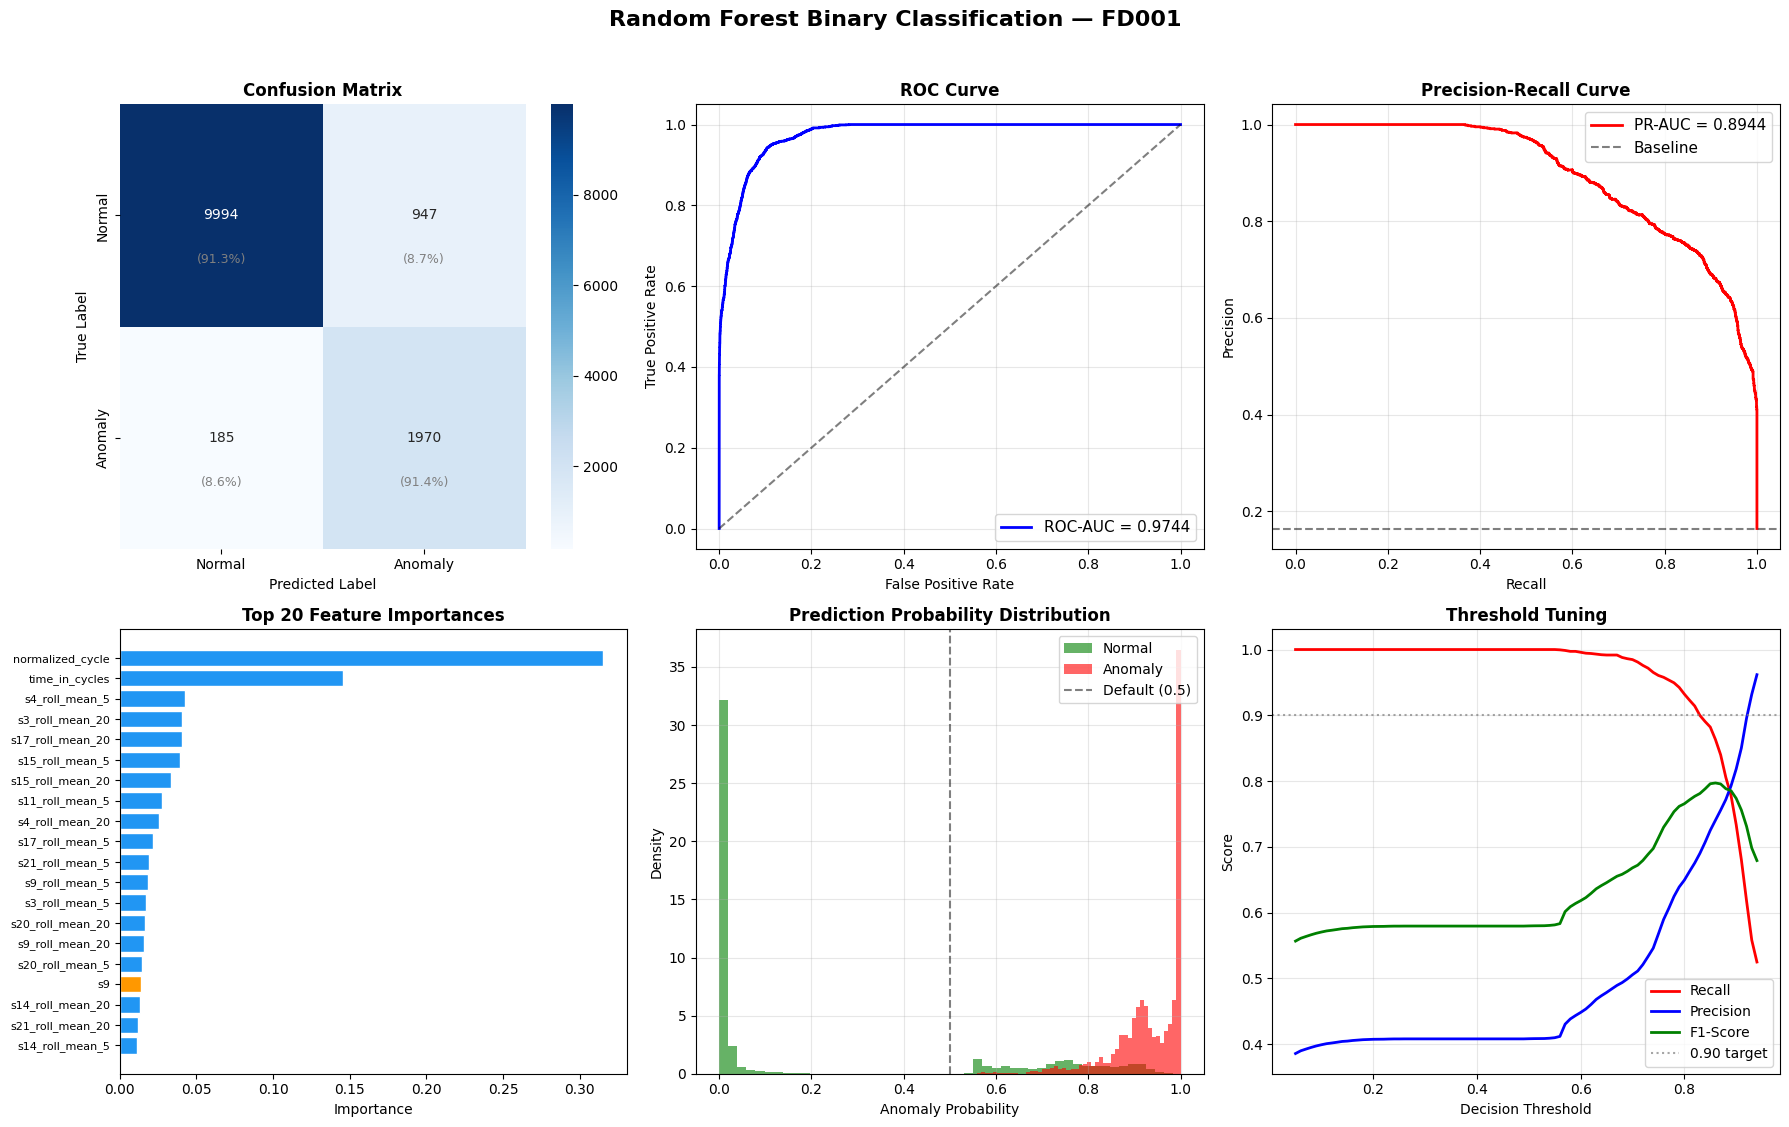


--- FD001 Engine-Level Results ---
  Engines: 100
  Accuracy:  0.8800
  Precision: 0.8413
  Recall:    0.9636 ★
  F1-Score:  0.8983

######################################################################
# Processing FD002
######################################################################
  FD002: 23 base features (removed 6 constant features)
  Train: (53759, 105), Anomaly ratio: 0.402
  Test:  (33991, 105), Anomaly ratio: 0.190
  Total features: 105

Training Random Forest for FD002
Training...
OOB Score: 1.0000
Optimal threshold: 0.87

--- FD002 Results ---
Accuracy:  0.9335
Precision: 0.7740
Recall:    0.9165  ★
F1-Score:  0.8392
ROC-AUC:   0.9821
PR-AUC:    0.9311

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.94      0.96     27549
     Anomaly       0.77      0.92      0.84      6442

    accuracy                           0.93     33991
   macro avg       0.88      0.93      0.90     33991
weighted avg       0.

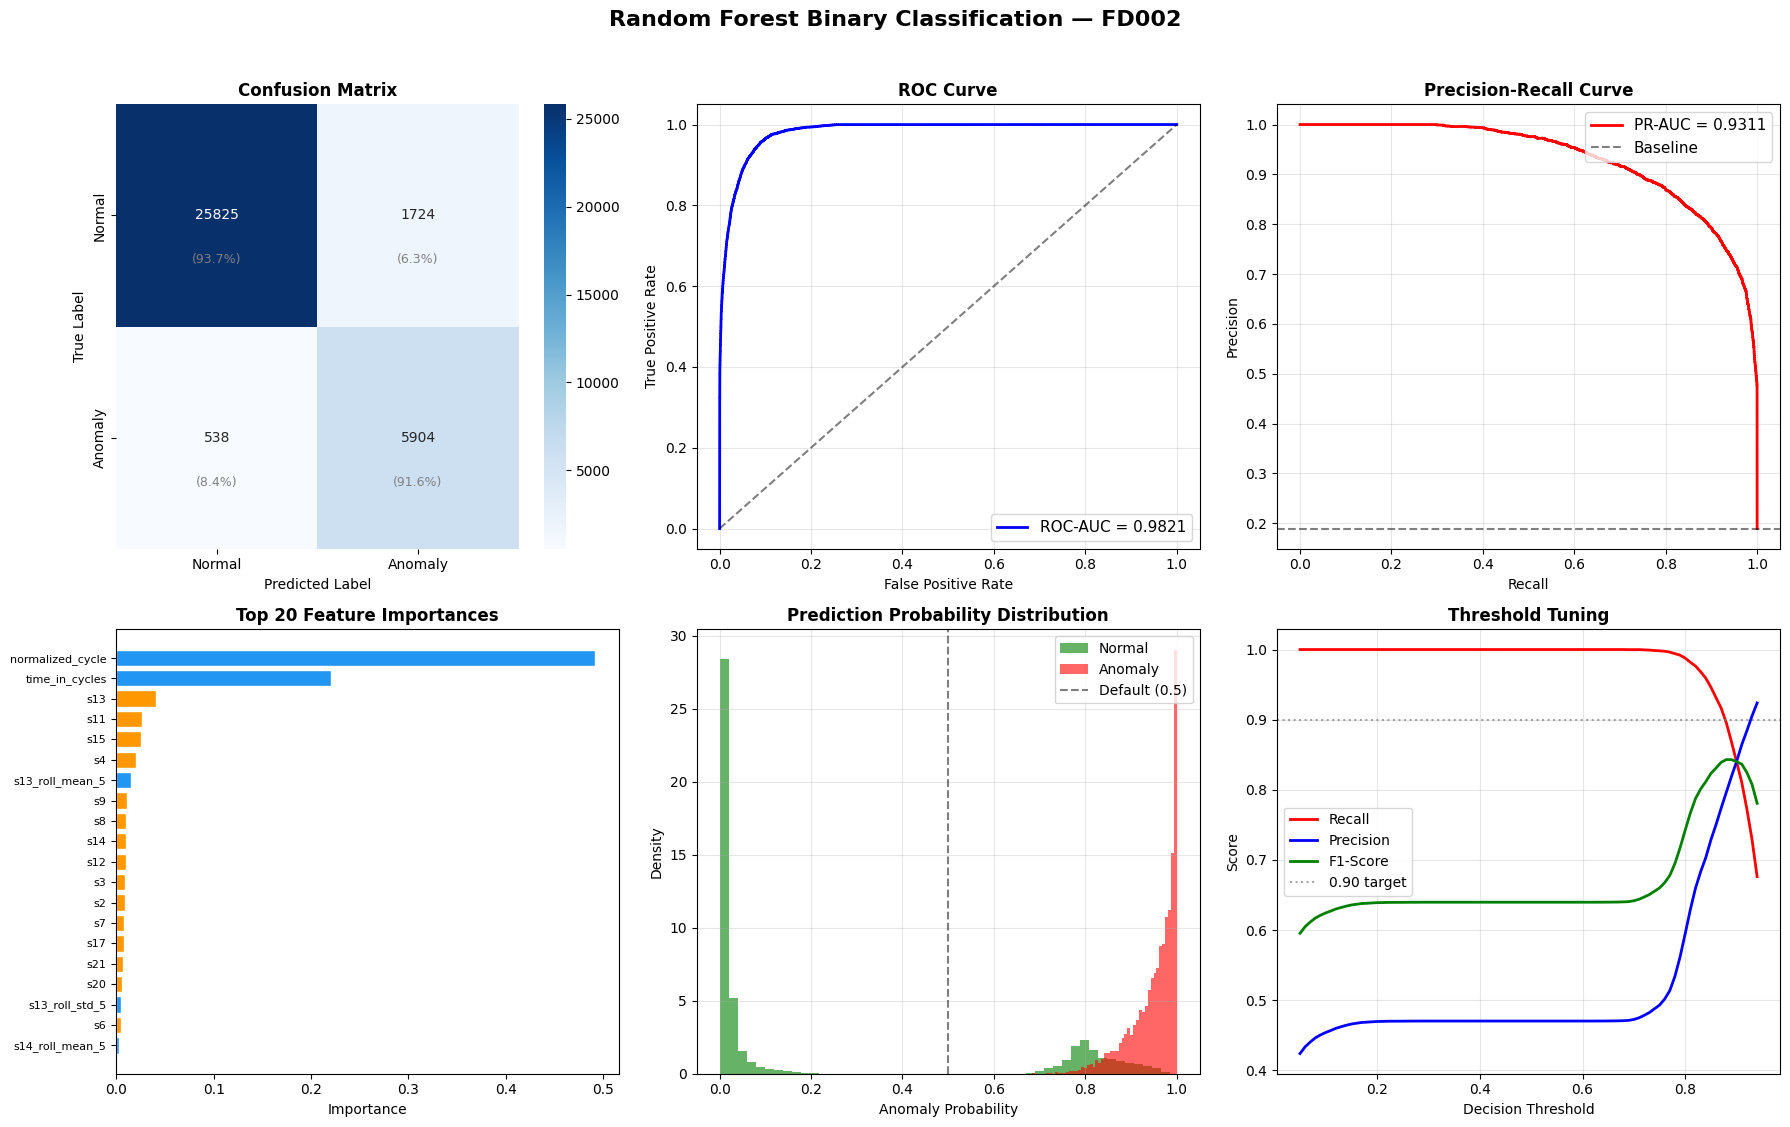


--- FD002 Engine-Level Results ---
  Engines: 259
  Accuracy:  0.9073
  Precision: 0.8580
  Recall:    0.9929 ★
  F1-Score:  0.9205

######################################################################
# Processing FD003
######################################################################
  FD003: 15 base features (removed 14 constant features)
  Train: (24720, 77), Anomaly ratio: 0.402
  Test:  (16596, 77), Anomaly ratio: 0.198
  Total features: 77

Training Random Forest for FD003
Training...
OOB Score: 1.0000
Optimal threshold: 0.80

--- FD003 Results ---
Accuracy:  0.9338
Precision: 0.7819
Recall:    0.9234  ★
F1-Score:  0.8467
ROC-AUC:   0.9834
PR-AUC:    0.9411

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.94      0.96     13308
     Anomaly       0.78      0.92      0.85      3288

    accuracy                           0.93     16596
   macro avg       0.88      0.93      0.90     16596
weighted avg       0.94

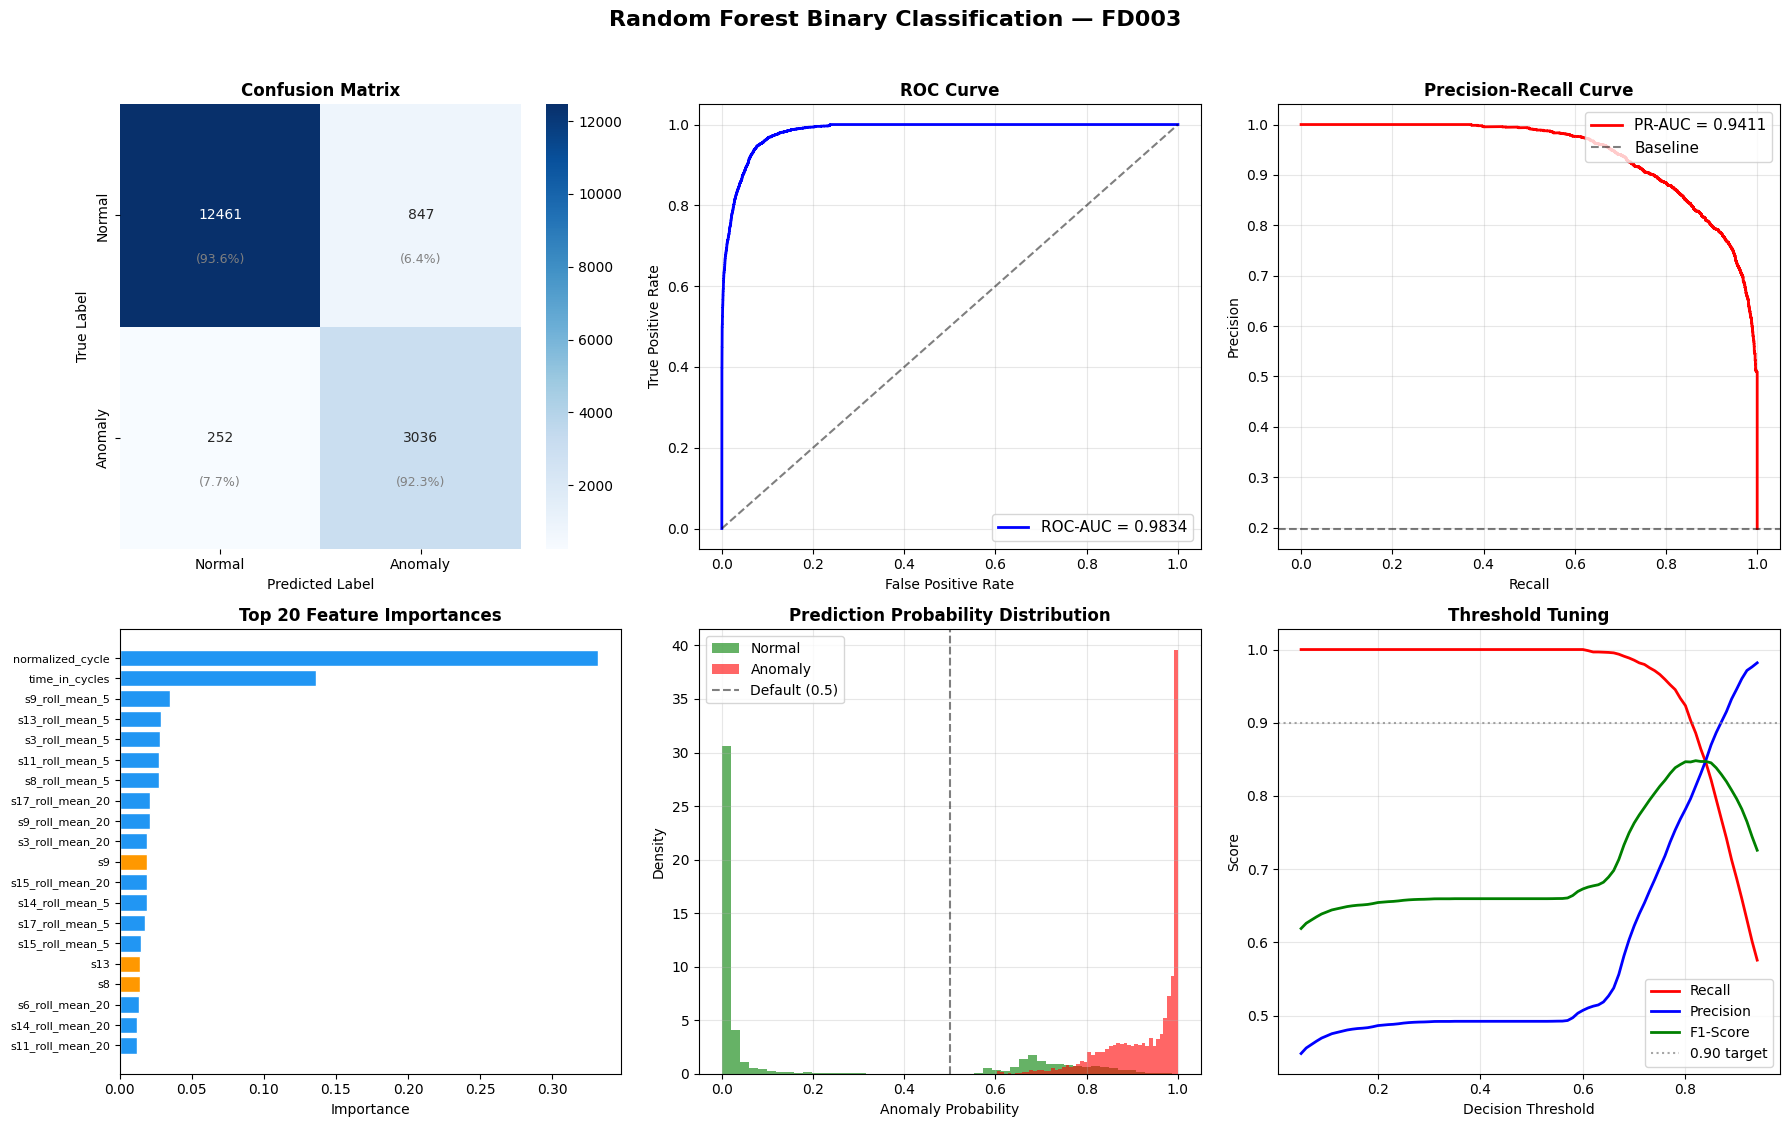


--- FD003 Engine-Level Results ---
  Engines: 100
  Accuracy:  0.9100
  Precision: 0.9091
  Recall:    0.9524 ★
  F1-Score:  0.9302

######################################################################
# Processing FD004
######################################################################
  FD004: 23 base features (removed 6 constant features)
  Train: (61249, 105), Anomaly ratio: 0.402
  Test:  (41214, 105), Anomaly ratio: 0.197
  Total features: 105

Training Random Forest for FD004
Training...
OOB Score: 1.0000
Optimal threshold: 0.87

--- FD004 Results ---
Accuracy:  0.9110
Precision: 0.7188
Recall:    0.9017  ★
F1-Score:  0.7999
ROC-AUC:   0.9726
PR-AUC:    0.8910

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.91      0.94     33085
     Anomaly       0.72      0.90      0.80      8129

    accuracy                           0.91     41214
   macro avg       0.85      0.91      0.87     41214
weighted avg       0.

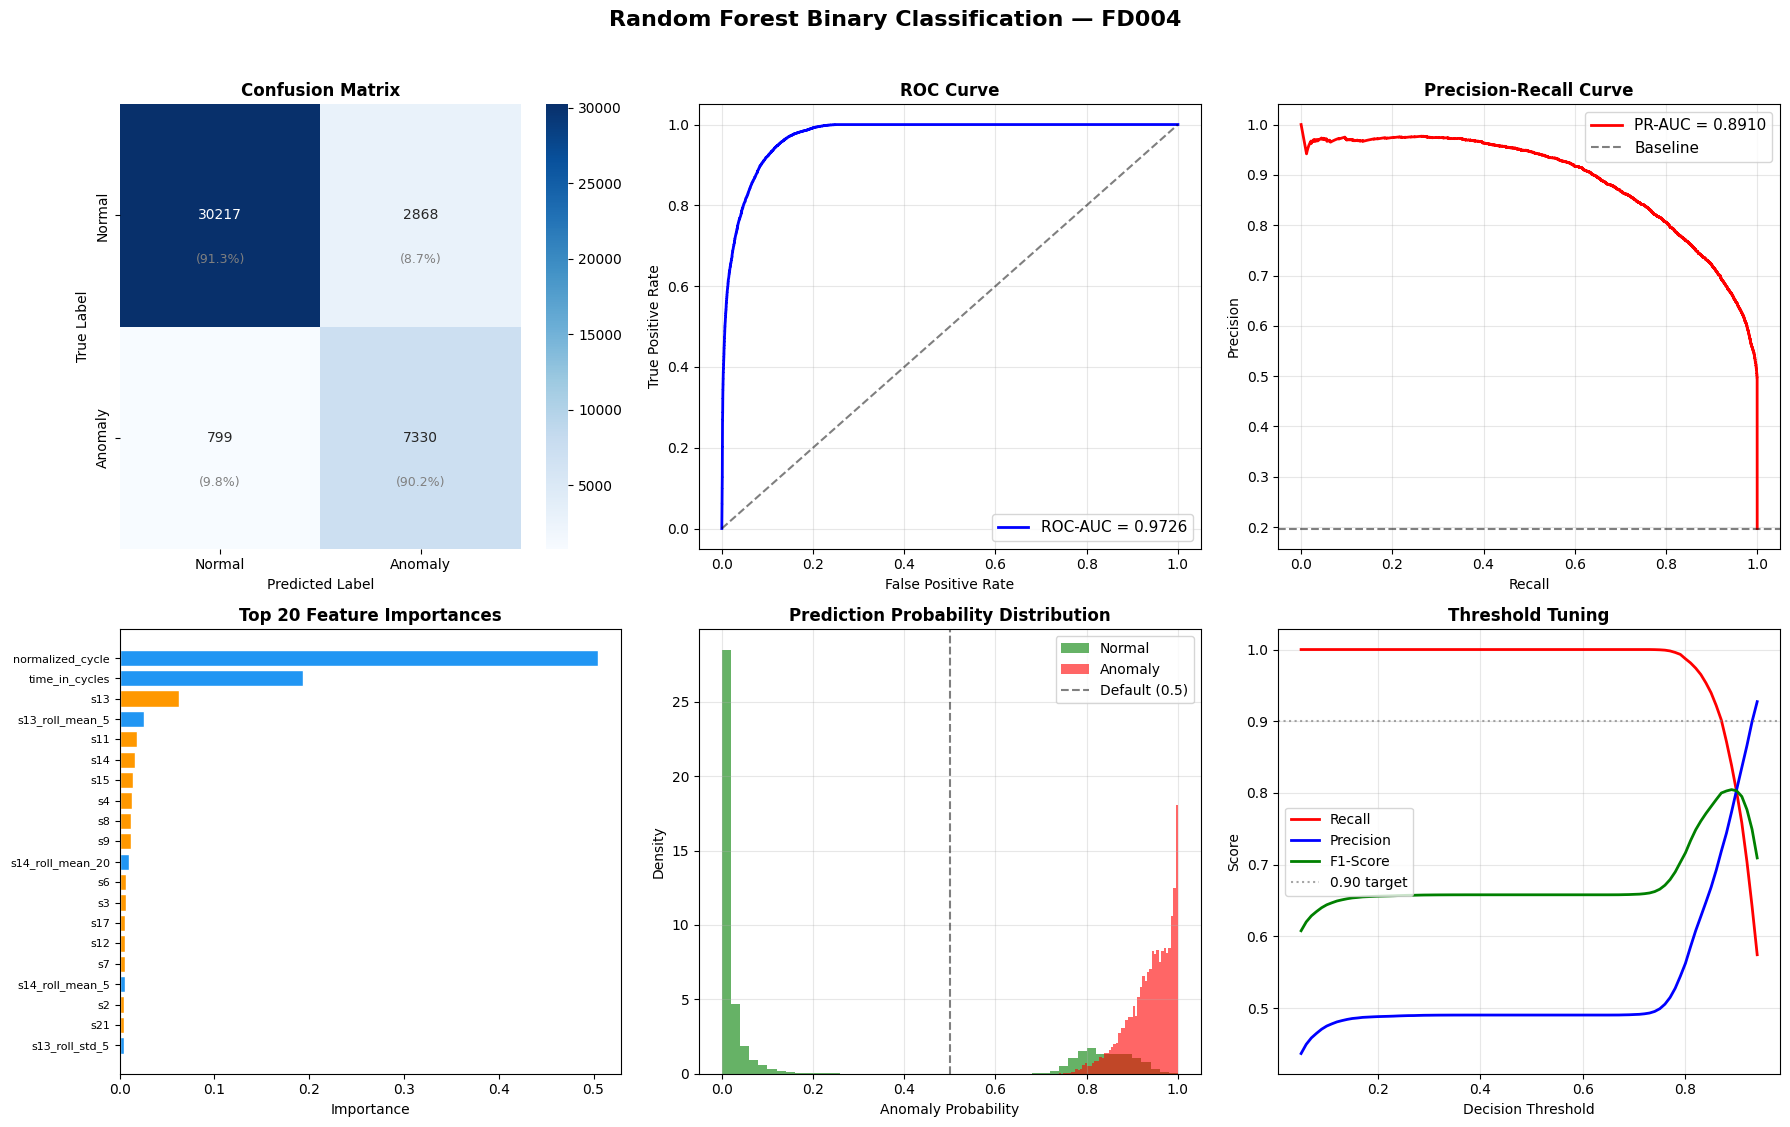


--- FD004 Engine-Level Results ---
  Engines: 248
  Accuracy:  0.8831
  Precision: 0.8439
  Recall:    0.9865 ★
  F1-Score:  0.9097


In [37]:
all_results = []
all_engine_results = []

for fd_name in ['FD001', 'FD002', 'FD003', 'FD004']:
    print(f"\n{'#'*70}")
    print(f"# Processing {fd_name}")
    print(f"{'#'*70}")

    data = datasets[fd_name]

    # Prepare data
    X_train, y_train, X_test, y_test, feature_cols, test_df = prepare_dataset(
        data['train'], data['test'], data['rul'],
        anomaly_ratio=0.40, dataset_name=fd_name
    )

    # Train and evaluate
    rf_model, y_pred, y_prob, results = train_and_evaluate_rf(
        X_train, y_train, X_test, y_test, feature_cols, fd_name
    )
    all_results.append(results)

    # Visualizations
    plot_results(y_test, y_pred, y_prob, feature_cols, rf_model, fd_name)

    # Engine-level evaluation
    engine_res = engine_level_evaluation(test_df, y_pred, y_prob, fd_name)
    all_engine_results.append(engine_res)


In [38]:
print("=" * 85)
print("SUMMARY: Timestep-Level Results (All Datasets)")
print("=" * 85)

results_df = pd.DataFrame(all_results).set_index('dataset')
print(results_df.to_string(float_format='%.4f'))

print(f"\nMean Recall:    {results_df['recall'].mean():.4f}")
print(f"Mean F1-Score:  {results_df['f1_score'].mean():.4f}")
print(f"Mean ROC-AUC:   {results_df['roc_auc'].mean():.4f}")

print("\n" + "=" * 85)
print("SUMMARY: Engine-Level Results (All Datasets)")
print("=" * 85)

engine_df = pd.DataFrame(all_engine_results).set_index('dataset')
print(engine_df.to_string(float_format='%.4f'))

SUMMARY: Timestep-Level Results (All Datasets)
         accuracy  precision  recall  f1_score  roc_auc  pr_auc  threshold
dataset                                                                   
FD001      0.9136     0.6754  0.9142    0.7768   0.9744  0.8944     0.8200
FD002      0.9335     0.7740  0.9165    0.8392   0.9821  0.9311     0.8700
FD003      0.9338     0.7819  0.9234    0.8467   0.9834  0.9411     0.8000
FD004      0.9110     0.7188  0.9017    0.7999   0.9726  0.8910     0.8700

Mean Recall:    0.9139
Mean F1-Score:  0.8157
Mean ROC-AUC:   0.9781

SUMMARY: Engine-Level Results (All Datasets)
         engine_accuracy  engine_precision  engine_recall  engine_f1
dataset                                                             
FD001             0.8800            0.8413         0.9636     0.8983
FD002             0.9073            0.8580         0.9929     0.9205
FD003             0.9100            0.9091         0.9524     0.9302
FD004             0.8831            0.8439

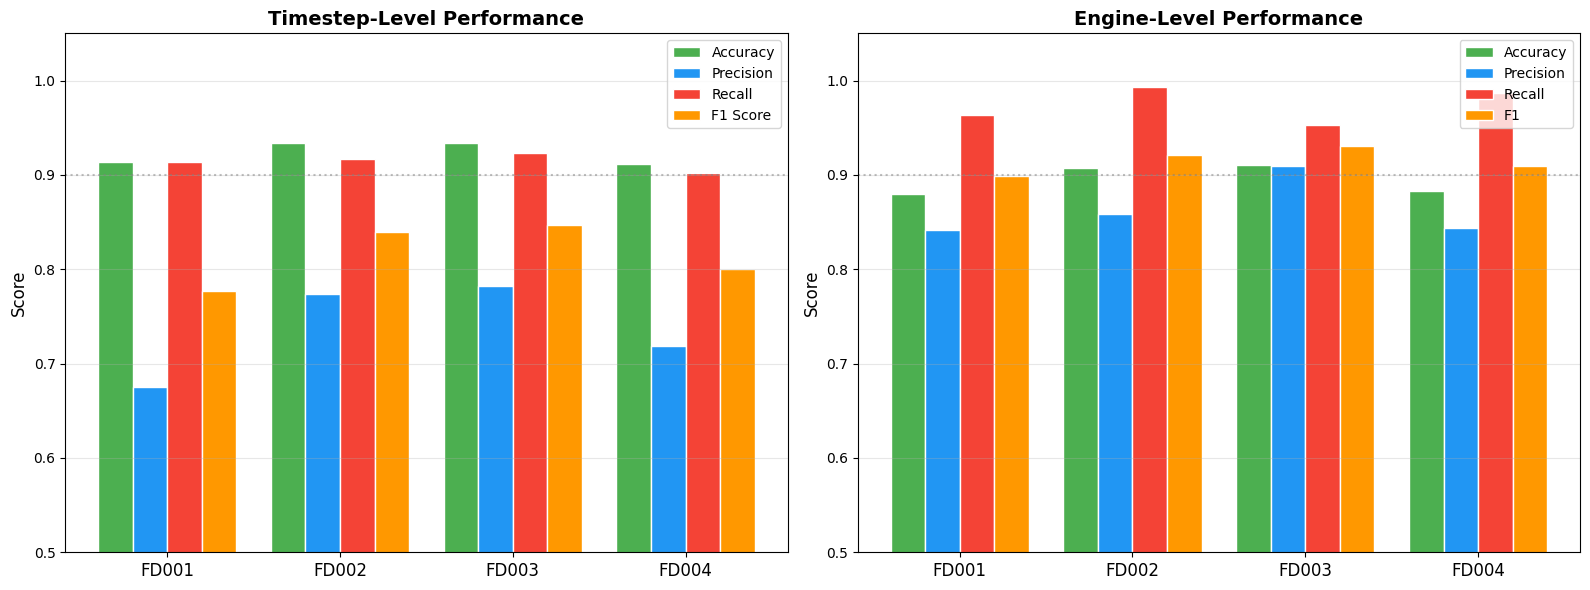

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(results_df))
width = 0.2
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
colors = ['#4CAF50', '#2196F3', '#F44336', '#FF9800']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    axes[0].bar(x + i * width, results_df[metric], width,
                label=metric.replace('_', ' ').title(), color=color, edgecolor='white')

axes[0].set_xticks(x + 1.5 * width)
axes[0].set_xticklabels(results_df.index, fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Timestep-Level Performance', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].set_ylim(0.5, 1.05)
axes[0].axhline(y=0.9, color='gray', linestyle=':', alpha=0.5)
axes[0].grid(axis='y', alpha=0.3)

metrics_e = ['engine_accuracy', 'engine_precision', 'engine_recall', 'engine_f1']
for i, (metric, color) in enumerate(zip(metrics_e, colors)):
    axes[1].bar(x + i * width, engine_df[metric], width,
                label=metric.replace('engine_', '').replace('_', ' ').title(),
                color=color, edgecolor='white')

axes[1].set_xticks(x + 1.5 * width)
axes[1].set_xticklabels(engine_df.index, fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Engine-Level Performance', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].set_ylim(0.5, 1.05)
axes[1].axhline(y=0.9, color='gray', linestyle=':', alpha=0.5)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
